<a href="https://colab.research.google.com/github/tarannump096-cpu/NLP/blob/main/NLP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/noisy_email_spam_dataset.csv")

In [ ]:
df

,label,email_text
0,spam,Hot deal!!! buy followers!!! http://boost-soci...
1,ham,"Hey,\nI think there is a typo in the file."
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...
3,spam,click fast!!!! http://prize-drop.win
4,ham,<br>Don't forget to submit the assignment.
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...
7,spam,limited time!!!! FREE gift card!!! http://gift...
8,spam,hey u!!! win iphone!!! go --> http://scamlink....
9,spam,Winner!!! send ur details ASAP!!! http://claim...


In [ ]:
df.columns

Index(['label', 'email_text'], dtype='object')

# Univariate Analysis



<Axes: xlabel='label'>

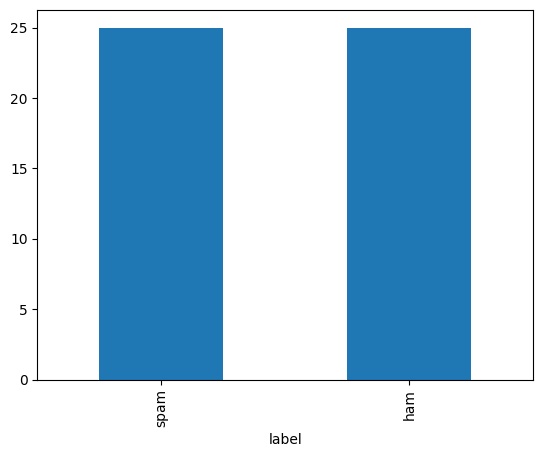

In [ ]:
#distribution of the target column
df["label"].value_counts().plot(kind="bar")

In [ ]:
df["char_count"]=df["email_text"].str.len()

In [ ]:
df

,label,email_text,char_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53
1,ham,"Hey,\nI think there is a typo in the file.",41
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,104
3,spam,click fast!!!! http://prize-drop.win,36
4,ham,<br>Don't forget to submit the assignment.,42
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51
7,spam,limited time!!!! FREE gift card!!! http://gift...,58
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,51
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54


/tmp/ipykernel_17060/1367858664.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["char_count"])


<Axes: xlabel='char_count', ylabel='Density'>

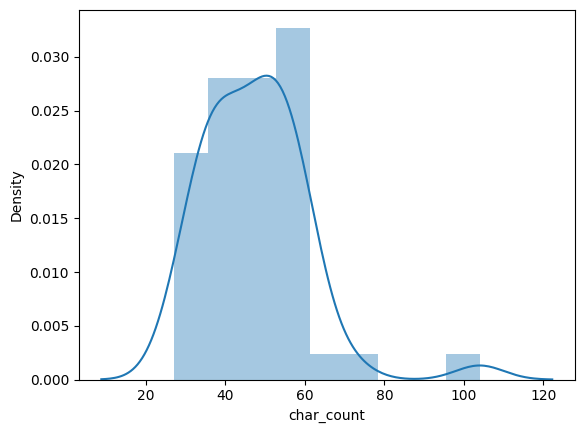

In [ ]:
sns.distplot(df["char_count"])

In [ ]:
import scipy.stats as stats

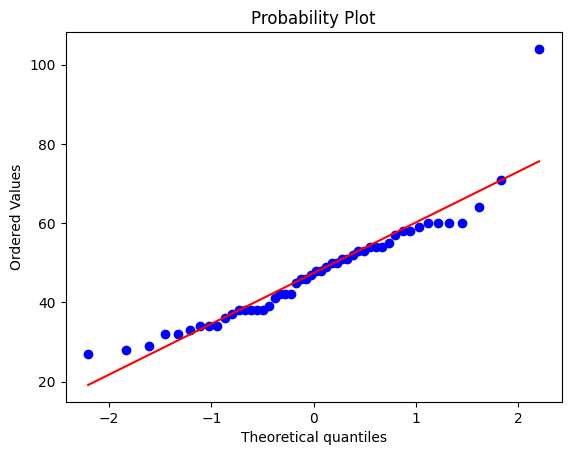

In [ ]:
stats.probplot(df["char_count"],dist="norm",plot=plt)
plt.show()

In [ ]:
spam_char_count=df[df["label"]=="spam"]["char_count"]

In [ ]:
ham_char_count=df[df["label"]=="ham"]["char_count"]

In [ ]:
#estimate avg char count for spam and ham--->CLT
def estimate_CLT(data,sample_size,no_of_samples):
    mean_lst=[]
    for i in range(no_of_samples):
        smaples=np.random.choice(data,size=sample_size)
        mean_lst.append(np.mean(smaples))
    mean_Array=np.array(mean_lst)
    return np.mean(mean_Array)


In [ ]:
sample_size=30
no_of_samples=1000
data=spam_char_count
avg_spam_char=estimate_CLT(data,sample_size,no_of_samples)

In [ ]:
avg_spam_char

np.float64(56.058033333333334)

In [ ]:
avg_ham_char=estimate_CLT(ham_char_count,30,1000)

In [ ]:
avg_ham_char

np.float64(38.7961)

In [ ]:
df.head()

,label,email_text,char_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53
1,ham,"Hey,\nI think there is a typo in the file.",41
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,104
3,spam,click fast!!!! http://prize-drop.win,36
4,ham,<br>Don't forget to submit the assignment.,42


In [ ]:
df["word_count"]=df["email_text"].str.split().apply(len)

In [ ]:
df

,label,email_text,char_count,word_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5
1,ham,"Hey,\nI think there is a typo in the file.",41,10
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,104,9
3,spam,click fast!!!! http://prize-drop.win,36,3
4,ham,<br>Don't forget to submit the assignment.,42,6
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,51,8
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6


/tmp/ipykernel_17060/1182839749.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["word_count"])


<Axes: xlabel='word_count', ylabel='Density'>

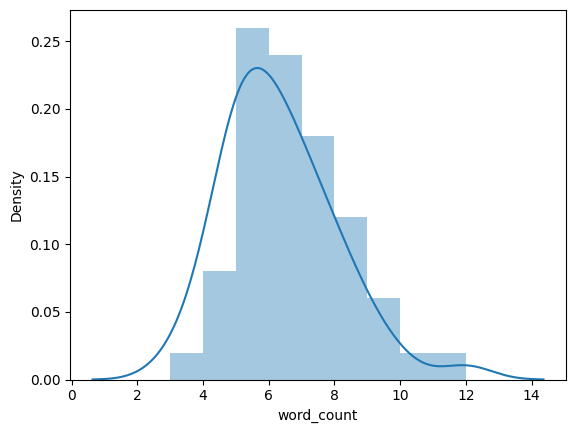

In [ ]:
sns.distplot(df["word_count"])

In [ ]:
spam_word_count=df[df["label"]=="spam"]["word_count"]

In [ ]:
ham_word_count=df[df["label"]=="ham"]["word_count"]

In [ ]:
def estimate_CLT(data,sample_size,no_of_samples):
    mean_lst=[]
    for i in range(no_of_samples):
        smaples=np.random.choice(data,size=sample_size)
        mean_lst.append(np.mean(smaples))
    mean_Array=np.array(mean_lst)
    return np.mean(mean_Array)


In [ ]:
avg_spam_words=estimate_CLT(spam_word_count,30,1000)

In [ ]:
avg_ham_words=estimate_CLT(ham_word_count,30,1000)


In [ ]:
avg_spam_words

np.float64(5.810733333333333)

In [ ]:
avg_ham_words

np.float64(6.847366666666667)

In [ ]:
df["html_count"]=df["email_text"].str.count("<")

In [ ]:
df.head()

,label,email_text,char_count,word_count,html_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5,0
1,ham,"Hey,\nI think there is a typo in the file.",41,10,0
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,104,9,6
3,spam,click fast!!!! http://prize-drop.win,36,3,0
4,ham,<br>Don't forget to submit the assignment.,42,6,1


In [ ]:
spam_html_count=df[df["label"]=="spam"]["html_count"]

In [ ]:
ham_html_count=df[df["label"]=="ham"]["html_count"]

In [ ]:
type(spam_html_count)

pandas.core.series.Series

In [ ]:
a1=np.sum(np.array(spam_html_count))

In [ ]:
a2=np.sum(np.array(ham_html_count))

In [ ]:
a1>a2

np.True_

In [ ]:
df["exclamatory_count"]=df["email_text"].str.count("!")

In [ ]:
spam_ex_count=df[df["label"]=="spam"]["exclamatory_count"]
ham_ex_count=df[df["label"]=="ham"]["exclamatory_count"]

In [ ]:
res=np.sum(np.array(spam_ex_count))>np.sum(np.array(ham_ex_count))

In [ ]:
res

np.True_

In [ ]:
df["count_url"]=df["email_text"].str.count("http")

In [ ]:
spam_url_count=df[df["label"]=="spam"]["count_url"]
ham_url_count=df[df["label"]=="ham"]["count_url"]

In [ ]:
res1=np.sum(np.array(spam_url_count))>np.sum(np.array(ham_url_count))

In [ ]:
res1

np.True_

# Bivariate Analysis



Text(0.5, 1.0, 'char_count for spam and ham')

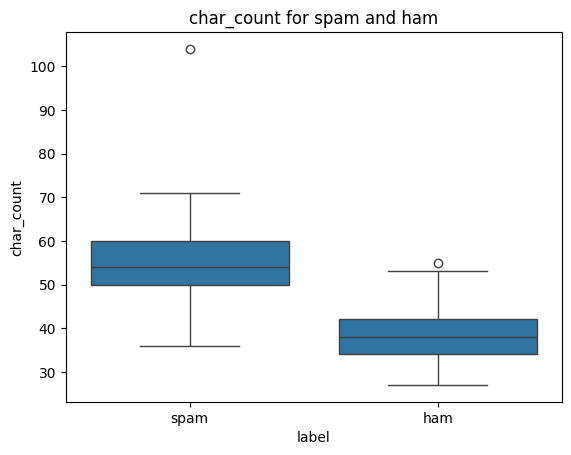

In [ ]:
sns.boxplot(x="label",y="char_count",data=df)
plt.title("char_count for spam and ham")

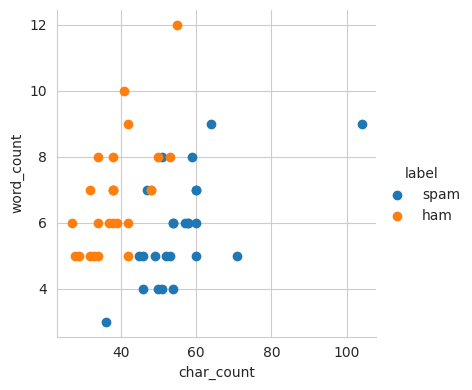

In [ ]:
sns.set_style("whitegrid")
sns.FacetGrid(df,hue="label",height=4).map(plt.scatter,"char_count","word_count").add_legend()
plt.show()

# Multi-Variate Analysis

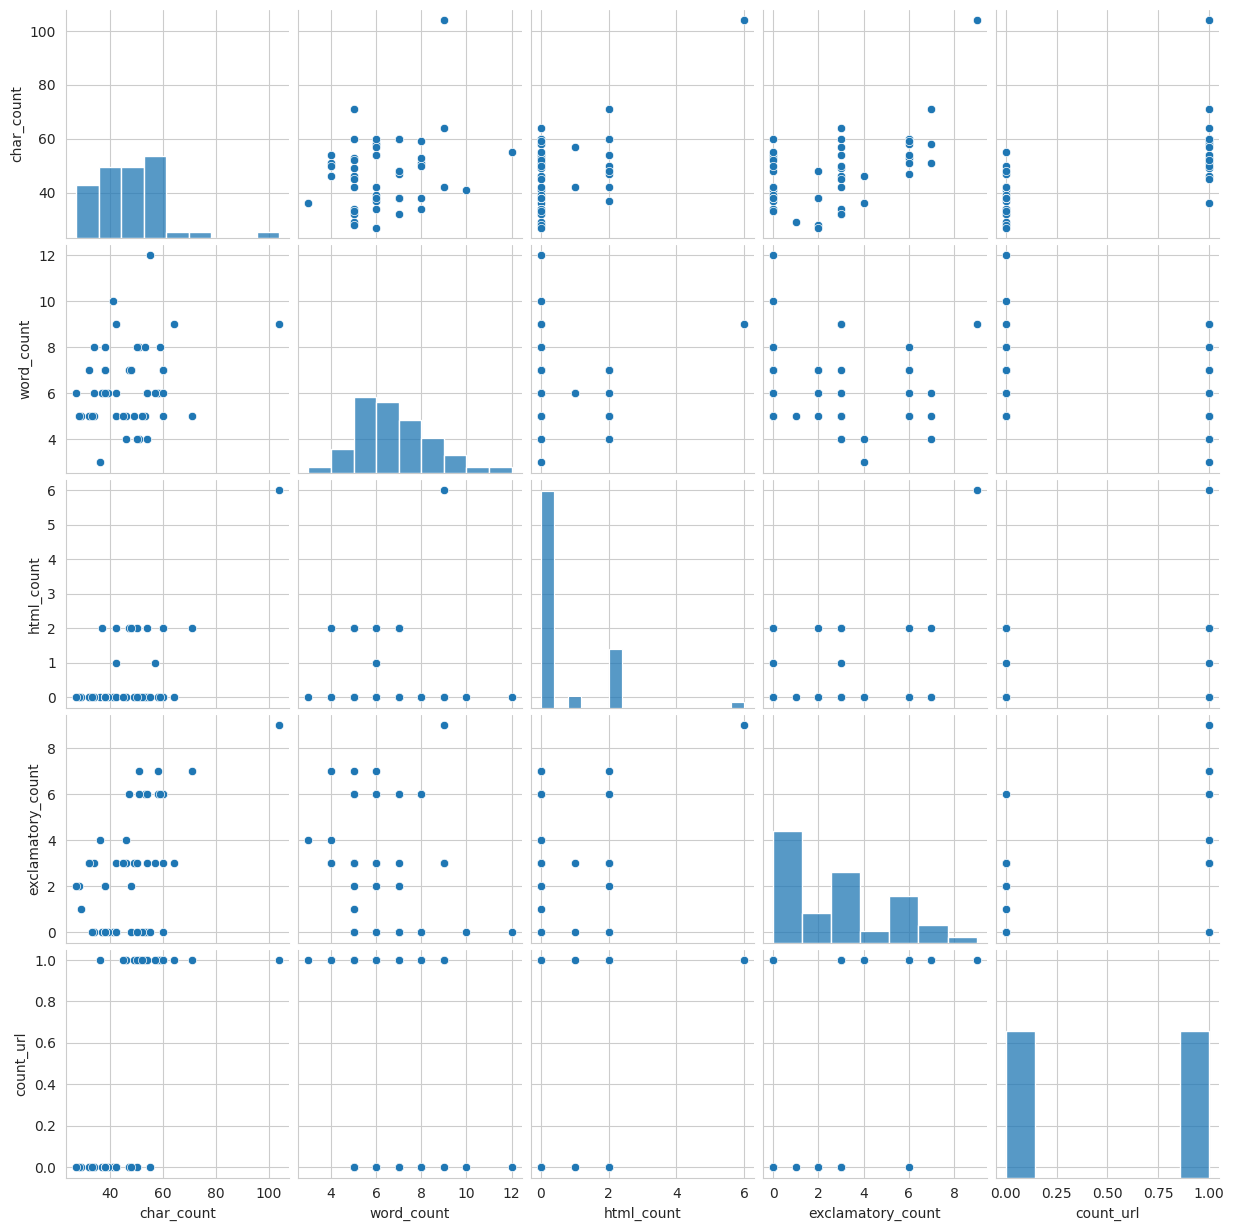

In [ ]:
sns.pairplot(df)
plt.show()